Forecast each user's watch hours for the next month.

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
import pandas as pd

df = pd.read_csv("lumen_watch_target.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 30000 non-null  int64  
 1   plan                    30000 non-null  object 
 2   country                 30000 non-null  object 
 3   device                  30000 non-null  object 
 4   tenure_months           30000 non-null  int64  
 5   watch_hours_t_minus_3   30000 non-null  float64
 6   watch_hours_t_minus_2   30000 non-null  float64
 7   watch_hours_t_minus_1   30000 non-null  float64
 8   watch_hours_next_month  30000 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 2.1+ MB


In [49]:
df.describe()

,user_id,tenure_months,watch_hours_t_minus_3,watch_hours_t_minus_2,watch_hours_t_minus_1,watch_hours_next_month
count,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,3.015000e+06,30.121167,14.557168,14.573499,14.566936,12.788219
std,8.660398e+03,17.069800,12.545740,12.200242,12.046275,11.931914
min,3.000000e+06,1.000000,0.570000,0.650000,0.670000,0.000000
25%,3.007500e+06,15.000000,6.640000,6.810000,6.920000,5.210000
50%,3.015000e+06,30.000000,11.030000,11.140000,11.170000,10.160000
75%,3.022499e+06,45.000000,18.190000,18.190000,18.140000,16.930000
max,3.029999e+06,59.000000,264.330000,236.740000,215.810000,207.180000


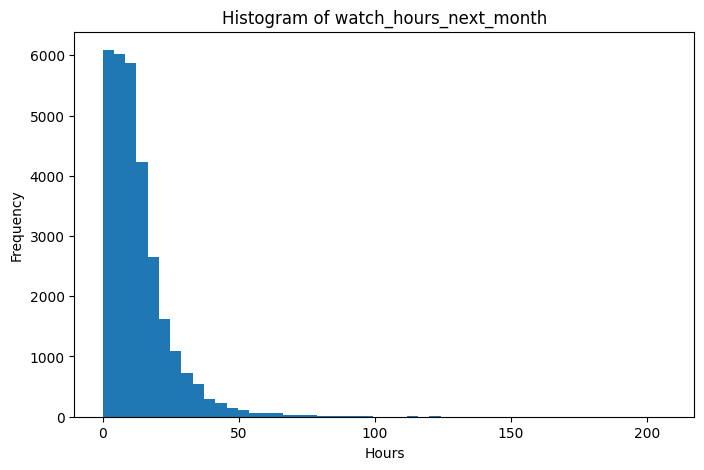

In [50]:
# check distribution of watch_hours_next_month

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['watch_hours_next_month'], bins = 50)
plt.title("Histogram of watch_hours_next_month")
plt.xlabel("Hours")
plt.ylabel("Frequency")

plt.show()

Text(0.02, 0.5, 'watch_hours_next_month')

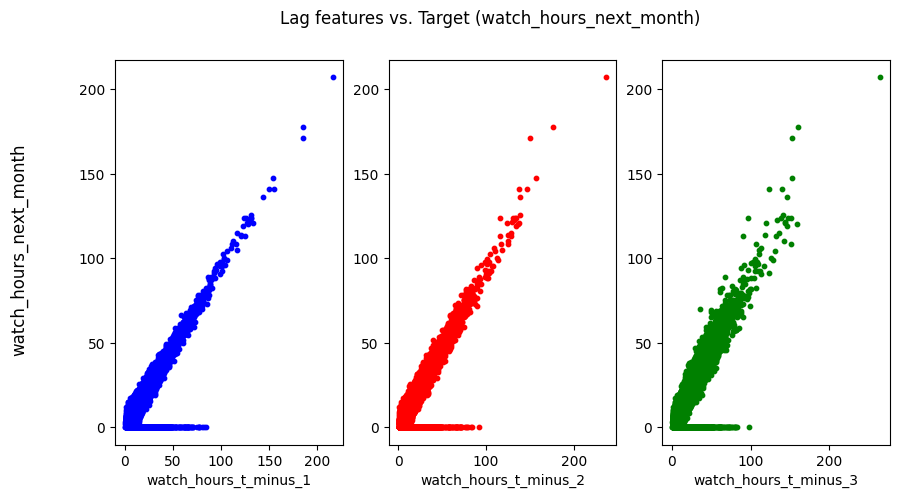

In [51]:
# plot lag features vs. target and check for linearity
x1 = df['watch_hours_t_minus_1']
x2 = df['watch_hours_t_minus_2']
x3 = df['watch_hours_t_minus_3']

y1 = df['watch_hours_next_month']

fig, ax = plt.subplots(1, 3, figsize = (10, 5))
ax[0].scatter(x1, y1, color = 'blue', s=10)
ax[0].set_xlabel("watch_hours_t_minus_1")

ax[1].scatter(x2, y1, color = 'red', s=10)
ax[1].set_xlabel("watch_hours_t_minus_2")

ax[2].scatter(x3, y1, color = 'green', s=10)
ax[2].set_xlabel("watch_hours_t_minus_3")

fig.suptitle("Lag features vs. Target (watch_hours_next_month)")
fig.supylabel("watch_hours_next_month")

watch_hours_t_minus_1 has the tightest linear band, makes sense since more recent behavior predicts next month better -- noisier with oldest dataset (watch_hours_t_minus_3)

<Axes: >

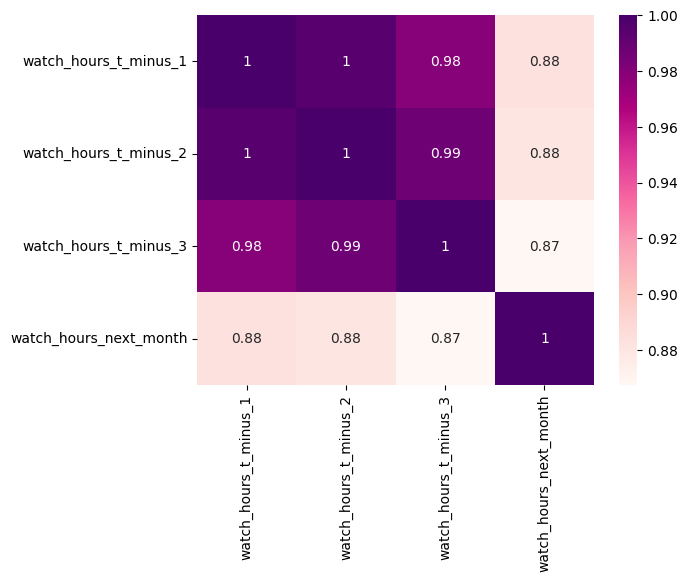

In [52]:
# correlation matrix of lag features with target
import seaborn as sns

lag_cols = ['watch_hours_t_minus_1', 'watch_hours_t_minus_2', 'watch_hours_t_minus_3']
sns.heatmap(df[lag_cols + ["watch_hours_next_month"]].corr(), annot=True, cmap="RdPu")

^ Confirmation of most recent watch_hours being the best predictor of next month's watch hours.

In [53]:
# categorical encoding
df = pd.get_dummies(df, columns = ['plan', 'device'], drop_first=True)

In [54]:
# group countries with smallest number of users, then encode
top_countries = df['country'].value_counts().head(8).index
df['country_grouped'] = df['country'].where(df['country'].isin(top_countries), other = "OTHER")
df['country_grouped']

,country_grouped
0,US
1,DE
2,OTHER
3,FR
4,FR
...,...
29995,FR
29996,US
29997,FR
29998,US


In [55]:
df = pd.get_dummies(df, columns = ['country_grouped'], drop_first=True)
df = df.drop(columns=['country'])

In [56]:
df.columns

Index(['user_id', 'tenure_months', 'watch_hours_t_minus_3',
       'watch_hours_t_minus_2', 'watch_hours_t_minus_1',
       'watch_hours_next_month', 'plan_premium', 'plan_standard', 'device_tv',
       'device_web', 'country_grouped_BR', 'country_grouped_DE',
       'country_grouped_ES', 'country_grouped_FR', 'country_grouped_GB',
       'country_grouped_IT', 'country_grouped_OTHER', 'country_grouped_US'],
      dtype='object')

In [57]:
# train/test split & save
import os

from sklearn.model_selection import train_test_split
X = df.drop(columns = ['watch_hours_next_month', 'user_id']) # data, drop labels and user_id cols
y = df['watch_hours_next_month'] # labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"Train: {len(X_train)}")
print(f"Test: {len(X_test)}")

Train: 24000
Test: 6000


In [58]:
os.makedirs("regression_data", exist_ok=True)
X_train.to_parquet("regression_data/X_train.parquet")
X_test.to_parquet("regression_data/X_test.parquet")
y_train.to_frame().to_parquet("regression_data/y_train.parquet") # convert from series to df, then to parquet (takes df as input)
y_test.to_frame().to_parquet("regression_data/y_test.parquet")

In [59]:
X_train = pd.read_parquet("regression_data/X_train.parquet")
X_test = pd.read_parquet("regression_data/X_test.parquet")
y_train = pd.read_parquet("regression_data/y_train.parquet").iloc[:, 0]
y_test = pd.read_parquet("regression_data/y_test.parquet").iloc[:, 0]

In [60]:
import numpy as np

# log-transform heavily-right skewed data, or linear regression model will fit poorly --
# customers with unusually high watch hours will strongly influence loss function

# train two versions of every model (raw vs. log-transformed)
y_train_log = np.log1p(y_train)

In [61]:
# to report errors in original scale, inverse-transform predictions (or error metrics will be in log-space instead of watch hours)
# predictions = np.expm1(model.predict(X_test))

In [62]:
# train 3 regressors -- LinearRegression, Ridge, RandomForest
# import models and initialize (one for raw, one for log)

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", LinearRegression())
])

lr_pipe_log = Pipeline([
    ("scale", StandardScaler()),
    ("model", LinearRegression())
])

ridge_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
ridge_pipe_log = Pipeline([
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

rf = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 20,
    n_jobs = -1,
    random_state=42
)
rf_log = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 20,
    n_jobs = -1,
    random_state=42
)

In [63]:
# fit to training data

# raw target fitting
lr_pipe.fit(X_train, y_train)
ridge_pipe.fit(X_train, y_train)
rf.fit(X_train, y_train)

# log-transform target fitting
lr_pipe_log.fit(X_train, y_train_log)
ridge_pipe_log.fit(X_train, y_train_log)
rf_log.fit(X_train, y_train_log)


RandomForestRegressor(max_depth=20, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def compute_metrics(name, y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  mask = y_true > 1
  mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
  return {'model' : name, 'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

In [65]:
all_metrics = []

all_metrics.append(compute_metrics('Linear Regression', y_test, lr_pipe.predict(X_test)))
all_metrics.append(compute_metrics('Linear Regression (log-transform)', y_test, np.expm1(lr_pipe_log.predict(X_test))))

all_metrics.append(compute_metrics('Ridge', y_test, ridge_pipe.predict(X_test)))
all_metrics.append(compute_metrics('Ridge (log-transform)', y_test, np.expm1(ridge_pipe_log.predict(X_test))))

all_metrics.append(compute_metrics('Random Forest', y_test, rf.predict(X_test)))
all_metrics.append(compute_metrics('Random Forest (log-transform)', y_test, np.expm1(rf_log.predict(X_test))))


In [66]:
results_df = pd.DataFrame(all_metrics)
results_df

,model,mae,rmse,r2,mape
0,Linear Regression,3.392036,5.418203,0.782206,28.084182
1,Linear Regression (log-transform),6.851533,37.496884,-9.430994,42.154182
2,Ridge,3.392038,5.418219,0.782205,28.084515
3,Ridge (log-transform),6.852227,37.518125,-9.442816,42.155397
4,Random Forest,3.612678,5.647346,0.763395,29.638101
5,Random Forest (log-transform),4.818497,7.074983,0.628648,34.769642


MAPE increases when y_true is near 0, use a stabilized version (SMAPE) or just report MAE in original units.

Log-transformation looked so much worse!
Move forward with LR or Ridge on raw target

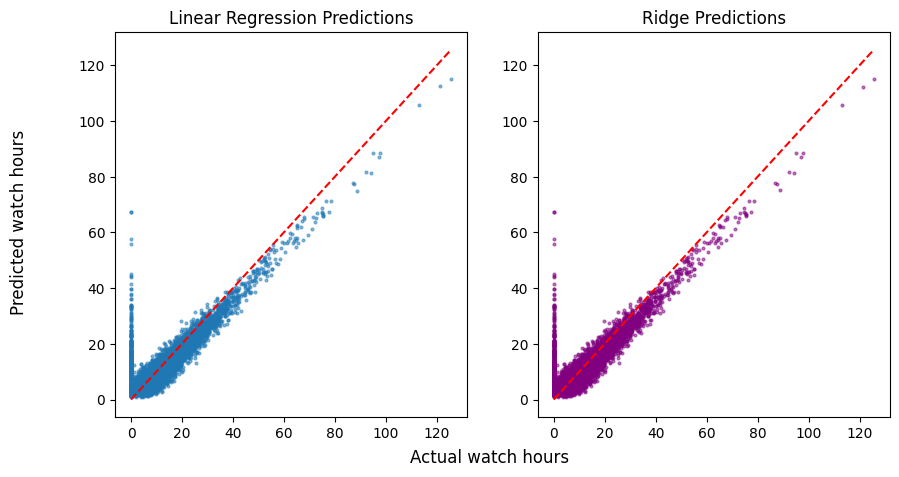

In [67]:
# predicted vs. actual scatter plots, with y=x refence line
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].scatter(y_test, lr_pipe.predict(X_test), alpha = 0.5, s=4)
ax[0].plot([0, y_test.max()], [0, y_test.max()], "r--")
ax[0].set_title("Linear Regression Predictions")

ax[1].scatter(y_test, ridge_pipe.predict(X_test), alpha = 0.5, s=4, color = 'purple')
ax[1].plot([0, y_test.max()], [0, y_test.max()], "r--")
ax[1].set_title("Ridge Predictions")

fig.supxlabel("Actual watch hours")
fig.supylabel("Predicted watch hours")

plt.savefig('/content/drive/MyDrive/figures/pred_vs_actual.png')
plt.show()

In [68]:
pwd

'/content'

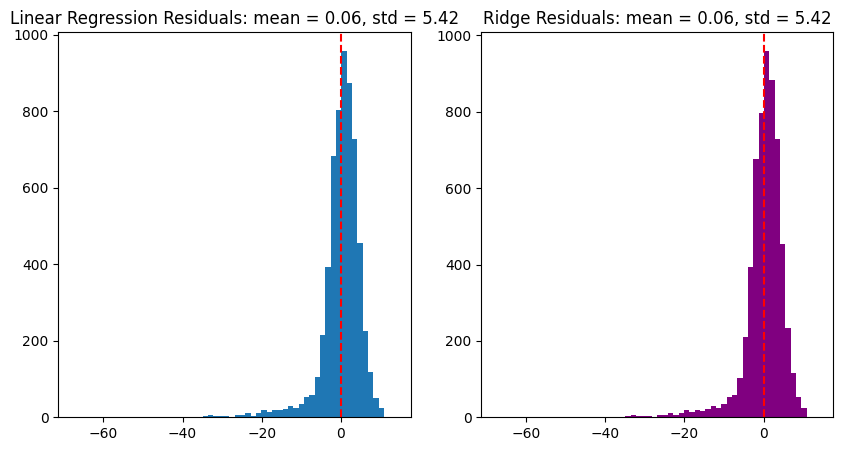

In [69]:
# residual distribution
lr_residuals = y_test - lr_pipe.predict(X_test)
r_residuals = y_test - ridge_pipe.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize = (10, 5))

ax[0].hist(lr_residuals, bins = 60)
ax[0].axvline(0, color = 'r', linestyle='--')
ax[0].set_title(f"Linear Regression Residuals: mean = {lr_residuals.mean():.2f}, std = {lr_residuals.std():.2f}")

ax[1].hist(r_residuals, bins=60, color = 'purple')
ax[1].axvline(0, color = 'r', linestyle='--')
ax[1].set_title(f"Ridge Residuals: mean = {r_residuals.mean():.2f}, std = {r_residuals.std():.2f}")

plt.savefig('/content/drive/MyDrive/figures/residuals.png')
plt.show()

Residuals expected to be centeredf at 0 and roughly symmetric -- skewed residuals suggest systematically biased model and hints at log-transformation.

In [70]:
r_residuals.max()

13.618469487916158

Recommendation: Ship ridge model to stabilize fit with many correlated features (watch_hours_t_minus_*).

MAE = ~3.4 hours

Max residual: 13.6 (worst case error observed)

Caveats: Conditions that may potentially degrade the model: new users with no history, mass content launches, holidays